# Phase 4 — Answering the Question

**How has open-source activity around AI/ML repositories changed compared with general
software-development repositories from 2021 to 2026?**

CS 131 Final Project · Arushi Nirmal · Yixu Liu · [kgr-17/CS131_final_project](https://github.com/kgr-17/CS131_final_project)

---

### Where this input came from

| Stage | Size |
|---|---|
| Raw GH Archive, 1 day/quarter 21Q1–26Q3 (552 hourly `.json.gz`) | **273.5 GB / 85,339,283 events** |
| After PySpark on Dataproc (Phase 3) | **43 KB of CSV** |

Phase 1 profiled it at the command line, Phase 2 proved Excel and pandas cannot hold it,
Phase 3 ground it down with Spark. This notebook is the payoff: what does it *say*?

All logic lives in `analysis.py` so the notebook and the poster cannot drift apart.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display

import analysis

pd.set_option("display.width", 160)
monthly, growth = analysis.load()
print(f"monthly.csv      {monthly.shape[0]:>4} rows x {monthly.shape[1]} cols")
print(f"monthly_growth   {growth.shape[0]:>4} rows x {growth.shape[1]} cols")
monthly.head()

monthly.csv       692 rows x 8 cols
monthly_growth     46 rows x 5 cols


,month,repo_class,type,events,actors,repos,class_events,share_of_class
0,2021-01,ai_ml,CommitCommentEvent,16,7,10,13658,0.001171
1,2021-01,ai_ml,CreateEvent,1190,523,564,13658,0.087128
2,2021-01,ai_ml,DeleteEvent,294,82,97,13658,0.021526
3,2021-01,ai_ml,ForkEvent,859,764,576,13658,0.062894
4,2021-01,ai_ml,GollumEvent,14,5,5,13658,0.001025


## Step 1 — Do not trust the samples yet

Every quarterly data point is **one sampled day** of GH Archive. If that day is missing
hours, or the archive dropped whole event types that day, the point is an artifact — and
it will read as a real change in developer behaviour.

`monthly_growth.csv` already contains the trap:

In [2]:
growth[growth.repo_class == "ai_ml"].head(6)

,month,repo_class,class_events,prev_events,mom_growth_pct
0,2021-01,ai_ml,13658,NaN,NaN
1,2021-04,ai_ml,16370,13658.0,19.86
2,2021-07,ai_ml,14477,16370.0,-11.56
3,2021-10,ai_ml,4538,14477.0,-68.65
4,2022-01,ai_ml,18013,4538.0,296.94
5,2022-04,ai_ml,22809,18013.0,26.63


**−68.65% then +296.94%.** Neither happened. Both are the same short sampled day: first
as a fake crash, then as a fake recovery when the next quarter returns to normal.

So before any finding, two independent checks:

- **volume** — total events vs the median sampled day. Catches missing hourly files:
  every event type shrinks together.
- **mix** — share of human-interaction events (PR, star, issue, review) vs the median.
  Catches a day where the archive kept writing pushes but lost interactions: the total
  looks fine, the *shape* does not.

In [3]:
quality = analysis.flag_samples(monthly)
quality["quarter"] = quality["month"].map(analysis.quarter_label)
print(quality[["quarter", "month", "total", "volume_ratio", "mix_ratio", "usable", "reason"]]
      .round(3).to_string(index=False))

quarter   month   total  volume_ratio  mix_ratio  usable                                      reason
   21Q1 2021-01 2652900         0.788      1.330    True                                            
   21Q2 2021-04 3154449         0.937      1.270    True                                            
   21Q3 2021-07 2932937         0.871      1.278    True                                            
   21Q4 2021-10 1078139         0.320      1.034   False                missing hours in sampled day
   22Q1 2022-01 2874305         0.853      1.307    True                                            
   22Q2 2022-04 3132270         0.930      1.165    True                                            
   22Q3 2022-07 3367872         1.000      1.162    True                                            
   22Q4 2022-10 3247760         0.964      0.804    True                                            
   23Q1 2023-01 3155709         0.937      0.838    True                                   

In [4]:
print("REJECTED:")
for _, r in quality[~quality.usable].iterrows():
    print(f"  {r.quarter} ({r.month})  vol={r.volume_ratio:.2f}  mix={r.mix_ratio:.2f}  -> {r.reason}")
print(f"\nusable: {quality.usable.sum()} / {len(quality)} sampled days")

REJECTED:
  21Q4 (2021-10)  vol=0.32  mix=1.03  -> missing hours in sampled day
  26Q2 (2026-04)  vol=1.11  mix=0.49  -> upstream archive dropped interaction events
  26Q3 (2026-07)  vol=1.17  mix=0.03  -> upstream archive dropped interaction events

usable: 20 / 23 sampled days


The thresholds (0.50 and 0.60) are not tuned to taste — the nearest *usable* quarter sits
at 0.79 and 0.80, so both rejections clear the boundary by >1.6×. Nothing borderline is
being hidden.

The 2026-Q3 failure is worth seeing directly:

In [5]:
q = monthly[(monthly.month.isin(["2025-10", "2026-07"])) & (monthly.repo_class == "general")]
q.pivot(index="type", columns="month", values="events") \
 .loc[["PushEvent", "PullRequestEvent", "WatchEvent", "IssueCommentEvent"]] \
 .assign(**{"change": lambda d: (d["2026-07"] / d["2025-10"]).map("{:.2f}x".format)})

month,2025-10,2026-07,change
type,,,
PushEvent,2340215,3523821,1.51x
PullRequestEvent,227917,10806,0.05x
WatchEvent,87648,2382,0.03x
IssueCommentEvent,114840,4898,0.04x


Pushes hold steady; pull requests fall to 1/28th and stars to 1/34th. Developers did not
stop reviewing each other's code — **GH Archive stopped recording it**. Excluded.

## Step 2 — Build the series and the headline numbers

In [6]:
series = analysis.build_series(monthly, quality)
h = analysis.headline(series)
print(json.dumps(h, indent=2))

{
  "window": "21Q1\u201326Q1",
  "usable_quarters": 20,
  "excluded_quarters": [
    "21Q4",
    "26Q2",
    "26Q3"
  ],
  "ai_share_first_pct": 0.515,
  "ai_share_last_pct": 0.94,
  "ai_share_peak_pct": 2.264,
  "ai_share_peak_quarter": "23Q2",
  "peak_vs_start_x": 4.4,
  "pre_chatgpt_mean_share_pct": 0.61,
  "post_gpt4_mean_share_pct": 0.954,
  "structural_lift_x": 1.56,
  "ai_volume_growth_x": 2.35,
  "general_volume_growth_x": 1.28,
  "ai_cagr_pct": 18.7,
  "general_cagr_pct": 5.1,
  "peak_ai_repos": 5788,
  "peak_ai_actors": 19977,
  "prior_quarter_ai_actors": 3734,
  "star_intensity_mean_x": 4.03,
  "star_intensity_min_x": 2.12,
  "star_intensity_peak_x": 6.61,
  "ai_star_share_peak_pct": 35.0
}


## Finding 1 — Real growth, but AI is still a small slice of GitHub

In [7]:
ok = series[series.usable]
first, last = ok.iloc[0], ok.iloc[-1]
pd.DataFrame({
    "2021-Q1":  [f"{first.ai_ml:,}", f"{first.general:,}"],
    "2026-Q1":  [f"{last.ai_ml:,}",  f"{last.general:,}"],
    "growth":   [f"{h['ai_volume_growth_x']}x", f"{h['general_volume_growth_x']}x"],
    "CAGR":     [f"{h['ai_cagr_pct']}%/yr", f"{h['general_cagr_pct']}%/yr"],
}, index=["AI/ML repos", "General repos"])

,2021-Q1,2026-Q1,growth,CAGR
AI/ML repos,"13,658","32,140",2.35x,18.7%/yr
General repos,"2,639,242","3,386,909",1.28x,5.1%/yr


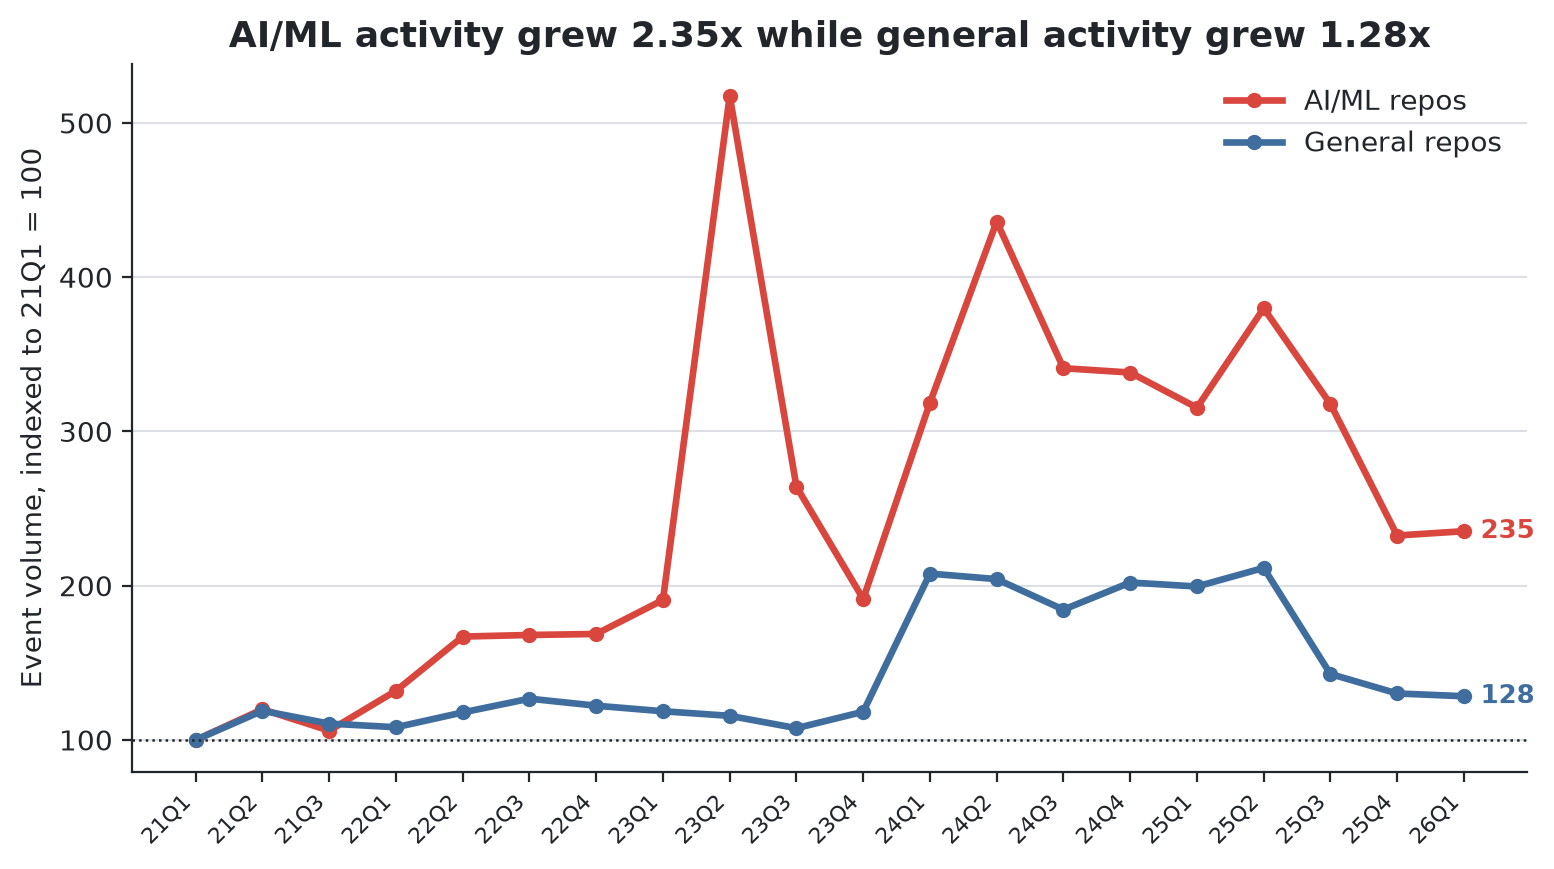

In [8]:
display(Image(filename="figures/fig2_indexed_volume.png"))

AI/ML activity grew **3.7× faster** than general activity — but from 0.5% of the platform.
After five years of the largest hype cycle in software, AI/ML repos are still **under 1%
of public GitHub events**. Both statements are true; the poster says both.

## Finding 2 — The 2023-Q2 spike is real and lines up with GPT-4

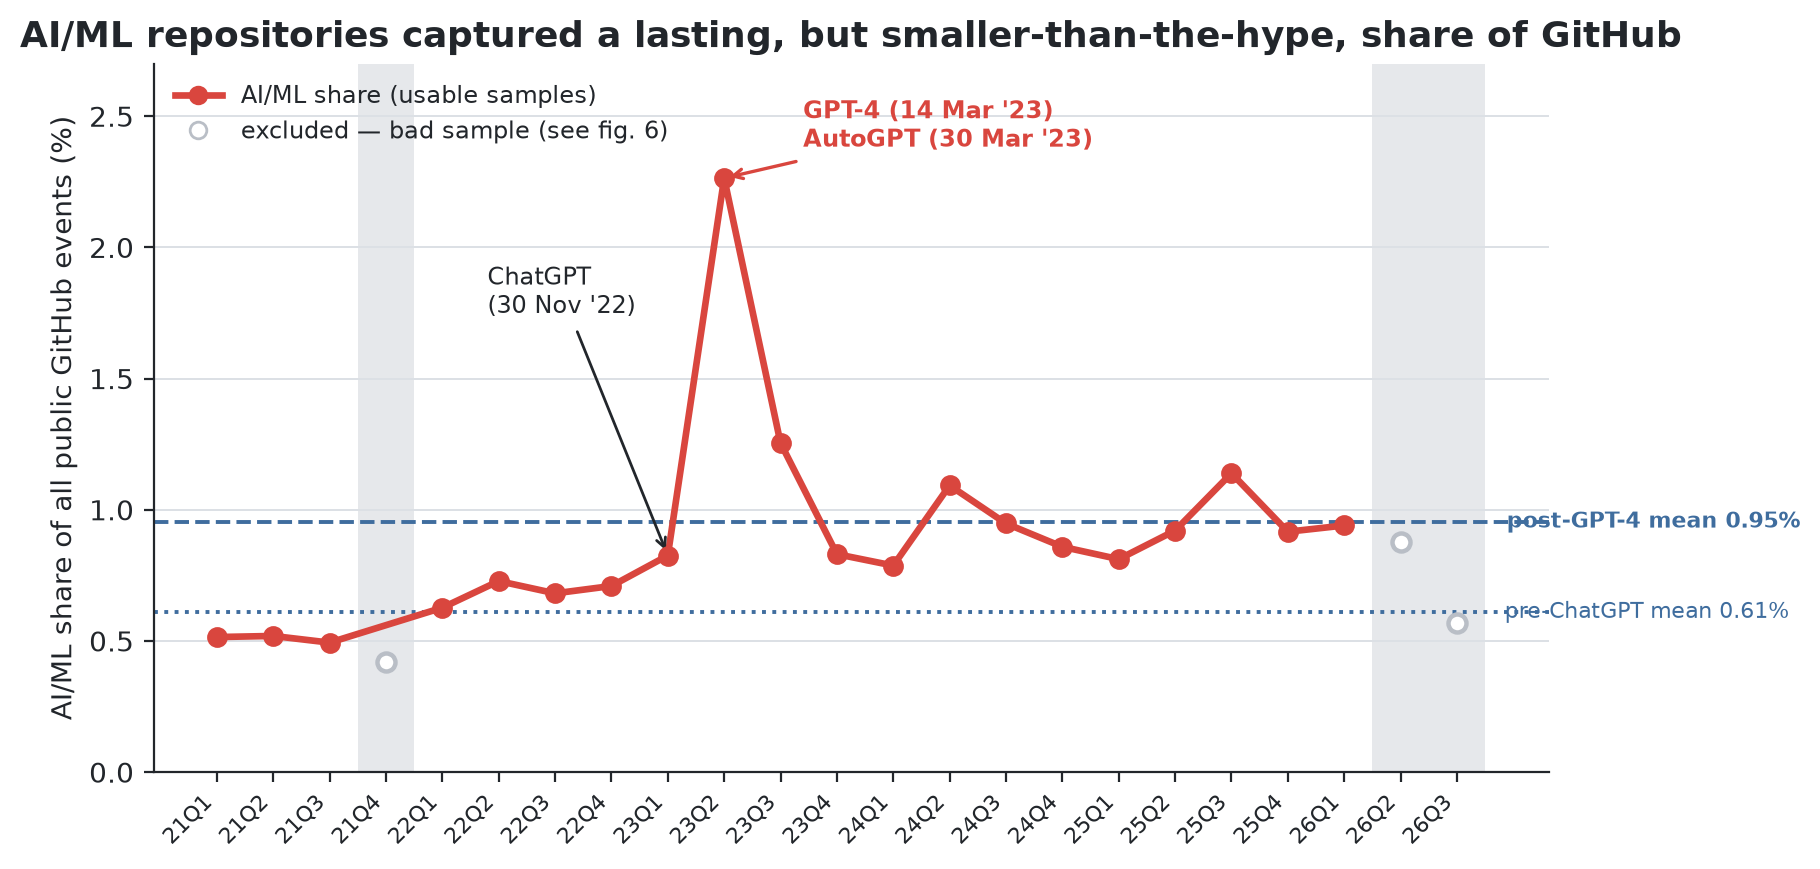

In [9]:
display(Image(filename="figures/fig1_ai_share.png"))

In [10]:
print(ok[["quarter", "ai_ml", "general", "ai_share_pct"]].round(3).to_string(index=False))

quarter  ai_ml  general  ai_share_pct
   21Q1  13658  2639242         0.515
   21Q2  16370  3138079         0.519
   21Q3  14477  2918460         0.494
   22Q1  18013  2856292         0.627
   22Q2  22809  3109461         0.728
   22Q3  22950  3344922         0.681
   22Q4  23039  3224721         0.709
   23Q1  26052  3129657         0.826
   23Q2  70683  3051450         2.264
   23Q3  36077  2840586         1.254
   23Q4  26143  3121006         0.831
   24Q1  43517  5484784         0.787
   24Q2  59552  5390697         1.093
   24Q3  46573  4868178         0.948
   24Q4  46190  5332496         0.859
   25Q1  43077  5264530         0.812
   25Q2  51875  5582477         0.921
   25Q3  43402  3766790         1.139
   25Q4  31758  3434167         0.916
   26Q1  32140  3386909         0.940


Share peaks at **2.26% in 23Q2** — **4.4×** the 21Q1 baseline — in the quarter containing
GPT-4 (14 Mar 2023) and AutoGPT (30 Mar 2023), one quarter after ChatGPT (30 Nov 2022).
That answers the proposal's sub-question "did activity jump after specific tool releases?"
with a clear **yes** for one enormous jump.

And it was **new people**, not the existing crowd working harder:

quarter  repos_ai_ml  actors_ai_ml
   23Q1         1944          3734
   23Q2         5788         19977

actors 23Q1 -> 23Q2: 5.4x in one quarter


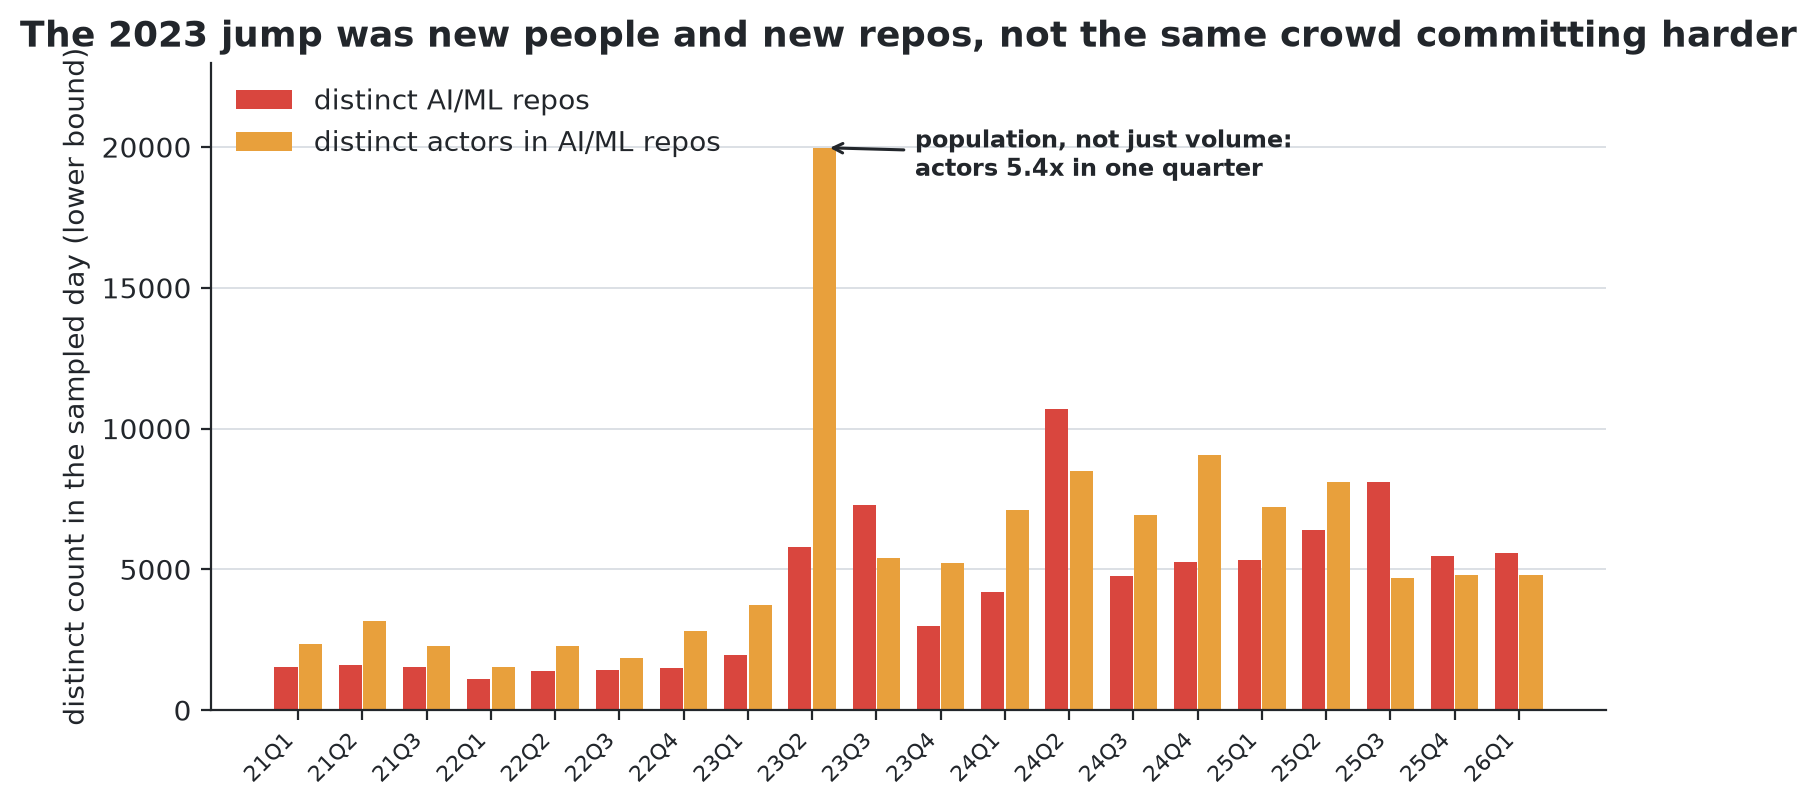

In [11]:
spike = ok[ok.month.isin(["2023-01", "2023-04"])][["quarter", "repos_ai_ml", "actors_ai_ml"]]
print(spike.to_string(index=False))
print(f"\nactors 23Q1 -> 23Q2: {spike.actors_ai_ml.iloc[1] / spike.actors_ai_ml.iloc[0]:.1f}x in one quarter")
display(Image(filename="figures/fig5_population.png"))

## Finding 3 — The retreat is partial: a 1.56× structural lift remains

In [12]:
pd.DataFrame({
    "mean AI/ML share": [f"{h['pre_chatgpt_mean_share_pct']}%", f"{h['post_gpt4_mean_share_pct']}%"],
}, index=["pre-ChatGPT (21Q1–22Q4)", "post-GPT-4 (23Q3–26Q1)"]).assign(
    **{"lift": ["—", f"{h['structural_lift_x']}x"]})

,mean AI/ML share,lift
pre-ChatGPT (21Q1–22Q4),0.61%,—
post-GPT-4 (23Q3–26Q1),0.954%,1.56x


Neither "AI took over GitHub" nor "it was pure hype." A wave of tourists came and went,
and left behind a base level **56% higher** than before.

## Finding 4 — The durable difference is attention, not code

In [13]:
usable_months = set(ok.month)
d = monthly[monthly.month.isin(usable_months)]
mix = (d.groupby(["repo_class", "type"])["events"].sum()
       / d.groupby("repo_class")["events"].sum()).unstack(0) * 100
mix["ratio_ai_over_gen"] = mix.ai_ml / mix.general
mix.sort_values("ai_ml", ascending=False).head(8).round(2)

repo_class,ai_ml,general,ratio_ai_over_gen
type,,,
PushEvent,43.49,59.24,0.73
WatchEvent,18.61,4.27,4.36
CreateEvent,9.45,12.89,0.73
PullRequestEvent,9.22,7.53,1.22
IssueCommentEvent,6.01,4.35,1.38
ForkEvent,3.68,1.18,3.13
DeleteEvent,2.68,3.04,0.88
PullRequestReviewEvent,2.32,2.19,1.06


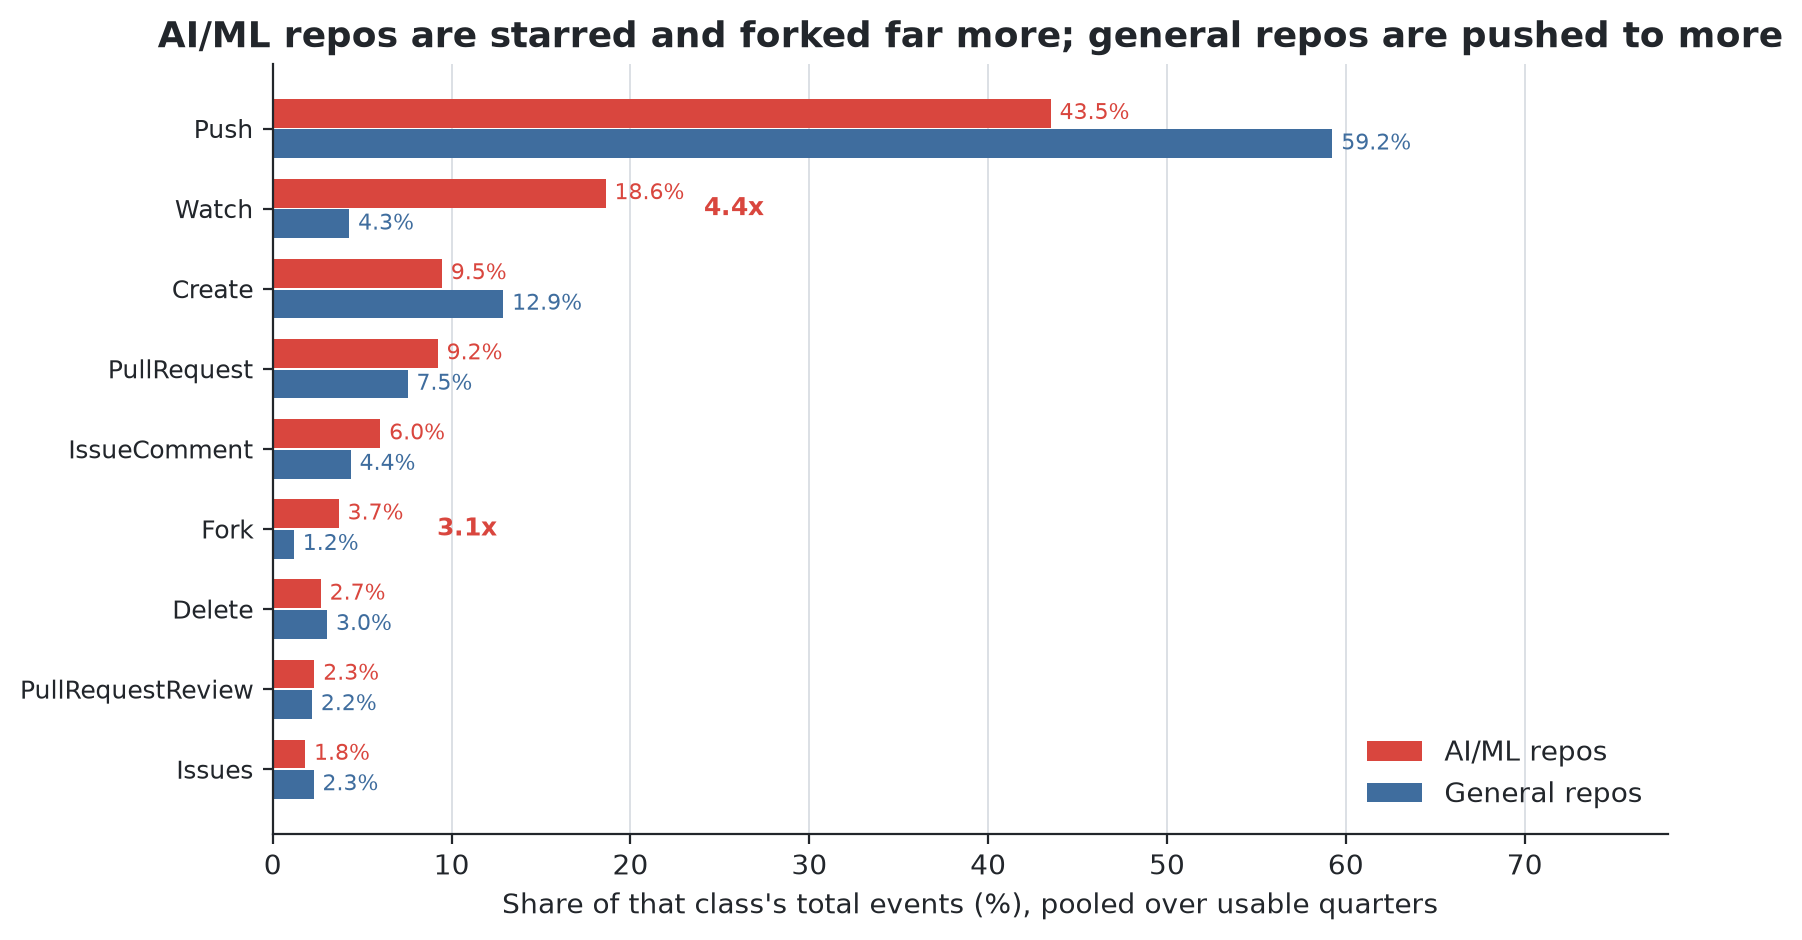

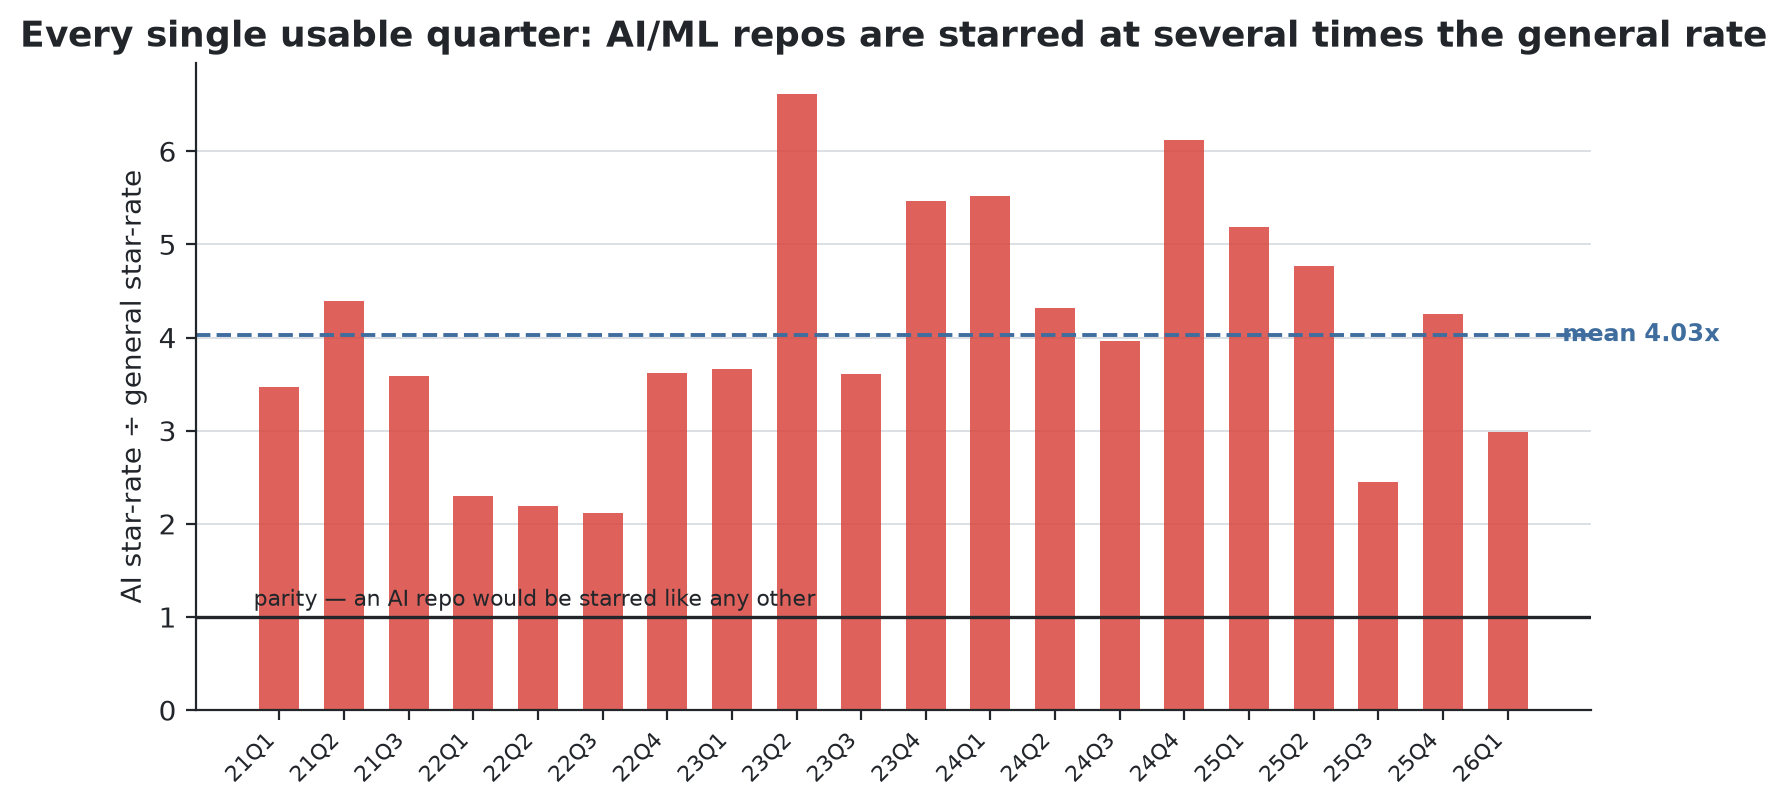

In [14]:
display(Image(filename="figures/fig3_event_mix.png"))
display(Image(filename="figures/fig4_star_intensity.png"))

In [15]:
print(f"star-intensity ratio (AI star-rate / general star-rate) across {len(ok)} usable quarters:")
print(f"  min  {h['star_intensity_min_x']}x")
print(f"  mean {h['star_intensity_mean_x']}x")
print(f"  max  {h['star_intensity_peak_x']}x  (23Q2 — 35% of ALL AI-repo events were stars)")
print(f"  quarters below parity (1.0x): {(ok.star_intensity < 1).sum()}")

star-intensity ratio (AI star-rate / general star-rate) across 20 usable quarters:
  min  2.12x
  mean 4.03x
  max  6.61x  (23Q2 — 35% of ALL AI-repo events were stars)
  quarters below parity (1.0x): 0


Stars and forks are **consumption** signals — someone found the repo, bookmarked it,
copied it. Pushes are **production**. AI/ML repos are starred 4.4× and forked 3.1× more
intensively than general repos while being pushed to *less*, and the star ratio never once
drops below parity in 20 quarters.

That is what a field dominated by a handful of large model and framework repos with
enormous audiences looks like: **most people are reading, not writing.**

## Step 3 — The data-quality figure for the poster

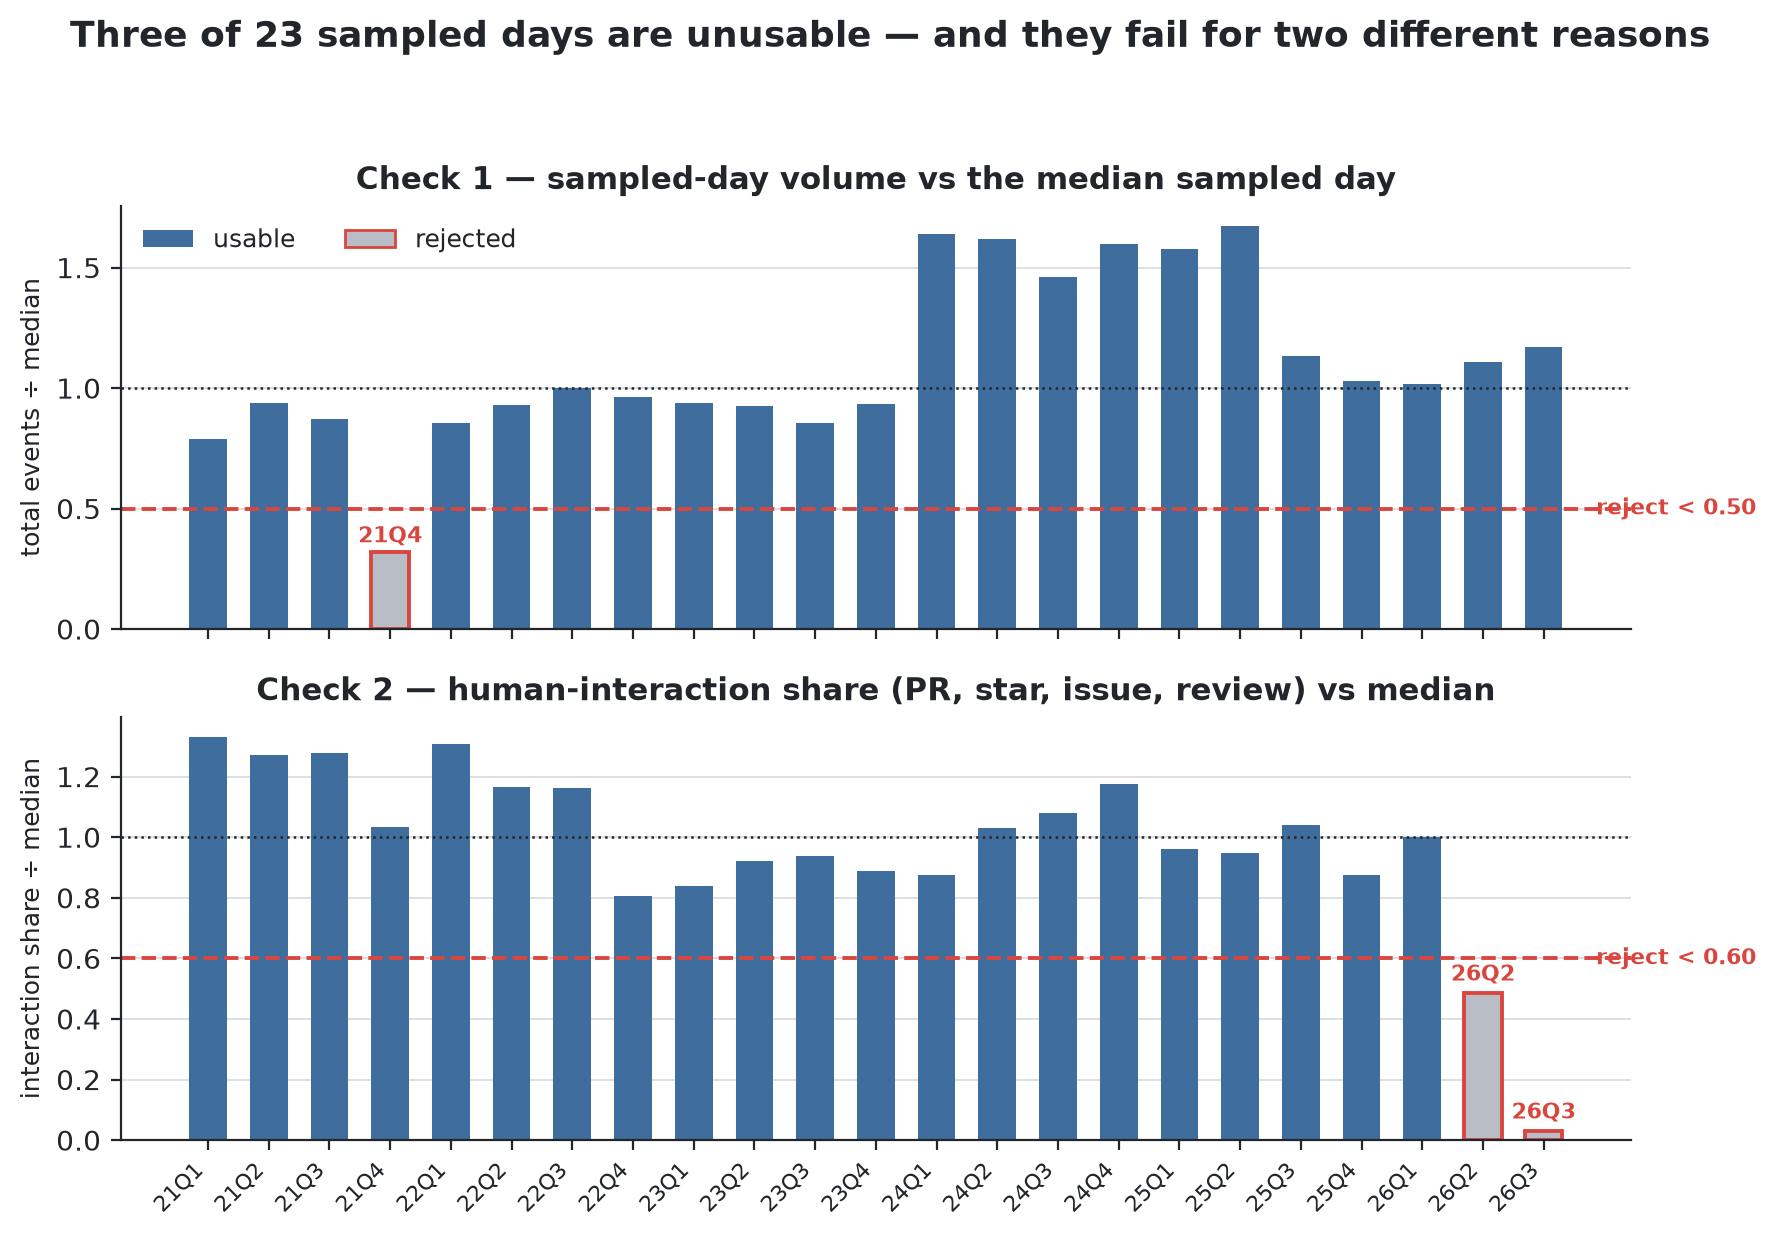

In [16]:
display(Image(filename="figures/fig6_data_quality.png"))

---

## Answer

**AI/ML open-source activity grew 2.35× from 2021-Q1 to 2026-Q1 while general software
activity grew 1.28× — 18.7%/yr vs 5.1%/yr. But AI/ML went only from 0.52% to 0.94% of all
public GitHub events, spiking to 2.26% in 2023-Q2 before giving most of it back. What
durably changed is not how much AI code gets written — it is how much attention it
attracts: AI/ML repos are starred at 4× the general rate in every single usable quarter.**

> **The AI boom shows up on GitHub as an attention boom first and a code boom second.**

## What would break this answer

1. **The keyword classifier is frozen in 2021 and decays.** It cannot match `claude`,
   `mcp`, `cursor`, `copilot`, `gemini`, `vllm`, `ollama` — tools that did not exist when
   the list was fixed. AI activity in 2024–26 is systematically **undercounted**, so
   2.35× is a **floor**. It also means part of the 23Q2 spike is a *naming* event: that
   was the quarter everything got named `*gpt*`.
2. **Name ≠ content.** `my-gpt-homework` counts as AI/ML; DeepMind research in a repo
   named after a person does not.
3. **Bots.** Phase 1 measured `github-actions[bot]` at 19,295 events/hour. Pushes are the
   most bot-contaminated signal and stars the least — which *strengthens* Finding 4.
4. **One day per quarter.** 23 days stand in for five years; a viral release or an outage
   moves a whole quarter. That was the price of a 2021→2026 span.

Full write-up: [`findings.md`](findings.md) · Poster: [`poster.pdf`](poster.pdf)